# **Problem Statement: Intelligent Campus Placement Prediction & Salary Estimation System**

A large recruitment analytics company wants to help colleges identify students who are likely to get placed and estimate their expected salary package before campus recruitment drives begin.

The company has collected student academic, technical, and extracurricular data such as CGPA, coding skills, DSA score, internships, projects, certifications, communication skills, hackathon participation, and open-source contributions.

The goal is to build a data-driven AI system that can:
1. Predict whether a student will get placed or not (placement_status) — Classification Problem.
2. Predict the expected salary package in LPA (salary_package_lpa) for placed students — Regression Problem.

The system should help:
- Colleges identify students needing training support.
- Placement cells improve placement strategies.
- Recruiters shortlist candidates efficiently.
- Students understand which skills most impact placement success and salary growth.

## **Business Objectives**
- Increase campus placement success rate.
- Identify key factors affecting placements and salary.
- Provide personalized improvement recommendations to students.
- Help training departments focus on high-impact skills like DSA, communication, internships, and projects.

### **Import Data and Required Packages**
Importing Pandas, Numpy, Matplotlib, Seaborn and Warings Library.

In [1]:
# import the necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

### **Import the CSV Data as Pandas DataFrame**

In [2]:
df = pd.read_csv("data/student_placement.csv")
df.head()

,branch,college_tier,cgpa,backlogs,coding_skills,dsa_score,aptitude_score,communication_skills,ml_knowledge,system_design,internships,projects_count,certifications,hackathons,open_source_contributions,extracurriculars,placement_status,salary_package_lpa
0,ECE,Tier-3,6.70,0,7.6,4.4,49.5,3.7,6.4,0.3,1,4,4,3,2,1,1,14.75
1,Chemical,Tier-2,5.70,0,5.4,7.9,72.0,8.3,6.3,1.9,0,4,0,0,0,0,0,NaN
2,EE,Tier-2,7.19,0,5.6,6.8,79.1,7.4,4.4,5.2,1,3,2,1,2,0,1,19.06
3,CE,Tier-2,6.48,0,5.2,3.1,48.4,5.0,1.1,6.7,1,4,3,0,0,0,0,NaN
4,CSE,Tier-2,6.71,1,5.9,4.7,61.2,4.3,2.7,2.8,1,2,0,3,0,1,1,13.42


### **Shape of the dataset**

In [3]:
df.shape

(100000, 18)

### **Dataset Info**

The dataset contains 1lac rows and 18 columns

| Column Name | Description |
|---|---|
| `branch` | Engineering branch or department of the student (e.g., CSE, ECE, EE, IT, Chemical, CE). |
| `college_tier` | Tier classification of the college based on reputation and placement opportunities (Tier-1, Tier-2, Tier-3). |
| `cgpa` | Cumulative Grade Point Average achieved by the student throughout academics. |
| `backlogs` | Number of academic backlogs or failed subjects. |
| `coding_skills` | Rating representing the student’s coding proficiency level. |
| `dsa_score` | Score representing knowledge of Data Structures and Algorithms. |
| `aptitude_score` | Score obtained in aptitude-related assessments. |
| `communication_skills` | Rating representing verbal and interpersonal communication ability. |
| `ml_knowledge` | Rating indicating knowledge of Machine Learning concepts and tools. |
| `system_design` | Rating representing understanding of system design concepts. |
| `internships` | Total number of internships completed by the student. |
| `projects_count` | Number of academic or personal projects completed. |
| `certifications` | Number of certifications earned in technical or professional domains. |
| `hackathons` | Number of hackathons participated in by the student. |
| `open_source_contributions` | Number of contributions made to open-source projects. |
| `extracurriculars` | Participation indicator or score related to extracurricular activities. |
| `placement_status` | Target column indicating whether the student got placed (`1 = Placed`, `0 = Not Placed`). |
| `salary_package_lpa` | Salary package offered to the student in Lakhs Per Annum (LPA). This value is generally available only for placed students. |

---

#### Target Variables

##### 1. Placement Prediction Target
- `placement_status`

Type:
- Classification Problem

Goal:
- Predict whether a student will get placed or not.

---

##### 2. Salary Prediction Target
- `salary_package_lpa`

Type:
- Regression Problem

Goal:
- Predict the expected salary package of placed students.

### **Data Checks to perform**

- Check Missing values
- Check Duplicates
- Check data type
- Check the number of unique values of each column
- Check statistics of data set
- Check various categories present in the different categorical column

In [4]:
# check missing values
print(f"Missing values in each column:\n{df.isnull().sum()}")

Missing values in each column:
branch                           0
college_tier                     0
cgpa                             0
backlogs                         0
coding_skills                    0
dsa_score                        0
aptitude_score                   0
communication_skills             0
ml_knowledge                     0
system_design                    0
internships                      0
projects_count                   0
certifications                   0
hackathons                       0
open_source_contributions        0
extracurriculars                 0
placement_status                 0
salary_package_lpa           31525
dtype: int64


In [5]:
# check duplicate rows
print(f"Number of duplicate rows: {df.duplicated().sum()}")

Number of duplicate rows: 0


In [6]:
# check data types
print(f"Data types of each column:\n{df.dtypes}")

Data types of each column:
branch                           str
college_tier                     str
cgpa                         float64
backlogs                       int64
coding_skills                float64
dsa_score                    float64
aptitude_score               float64
communication_skills         float64
ml_knowledge                 float64
system_design                float64
internships                    int64
projects_count                 int64
certifications                 int64
hackathons                     int64
open_source_contributions      int64
extracurriculars               int64
placement_status               int64
salary_package_lpa           float64
dtype: object


In [7]:
# check unique values in each column
print(f"Unique values in each column:\n{df.nunique()}")

Unique values in each column:
branch                          7
college_tier                    3
cgpa                          597
backlogs                        4
coding_skills                  91
dsa_score                      91
aptitude_score                765
communication_skills           91
ml_knowledge                  101
system_design                 101
internships                     4
projects_count                  6
certifications                  5
hackathons                      4
open_source_contributions       3
extracurriculars                4
placement_status                2
salary_package_lpa           1654
dtype: int64


In [8]:
# check statistical summary of data
df.describe()

,cgpa,backlogs,coding_skills,dsa_score,aptitude_score,communication_skills,ml_knowledge,system_design,internships,projects_count,certifications,hackathons,open_source_contributions,extracurriculars,placement_status,salary_package_lpa
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,68475.000000
mean,7.206381,0.547010,5.995147,5.500711,64.990511,5.990614,4.508752,4.008210,1.095040,2.397280,1.49985,0.745840,0.450990,1.151100,0.684750,17.308014
std,0.925235,0.862727,1.496302,1.781961,11.990892,1.496552,1.968278,1.778405,0.940264,1.242829,1.11407,0.884189,0.671061,0.965162,0.464618,2.601041
min,4.000000,0.000000,1.000000,1.000000,20.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,6.880000
25%,6.580000,0.000000,5.000000,4.300000,56.800000,5.000000,3.200000,2.800000,0.000000,1.000000,1.00000,0.000000,0.000000,0.000000,0.000000,15.530000
50%,7.210000,0.000000,6.000000,5.500000,65.000000,6.000000,4.500000,4.000000,1.000000,2.000000,1.00000,0.000000,0.000000,1.000000,1.000000,17.250000
75%,7.830000,1.000000,7.000000,6.700000,73.100000,7.000000,5.900000,5.200000,2.000000,3.000000,2.00000,1.000000,1.000000,2.000000,1.000000,19.040000
max,10.000000,3.000000,10.000000,10.000000,100.000000,10.000000,10.000000,10.000000,3.000000,5.000000,4.00000,3.000000,2.000000,3.000000,1.000000,28.330000


**Insight**

1. The average cgpa of students is 7.2 which indicates that the students are focusing on their college studies, coding_skills score, dsa_score, communication_skills and aptitude_score are above average level but the ml_knowledge and system_design which too important skills for getting placed in MNCs and good companies are just above average.

2. Around 50% students haven't done any internships, or participated in hackathons.

3. The average placement package is around 17.30 LPA.

### **Explore Data**

In [9]:
# define numerical & categorical columns
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
numerical_cols.remove("placement_status")

categorical_cols = df.select_dtypes(include="object").columns.tolist()
categorical_cols.append("placement_status")

print(f"Numerical columns: {numerical_cols}")
print(f"Categorical columns: {categorical_cols}")

Numerical columns: ['cgpa', 'backlogs', 'coding_skills', 'dsa_score', 'aptitude_score', 'communication_skills', 'ml_knowledge', 'system_design', 'internships', 'projects_count', 'certifications', 'hackathons', 'open_source_contributions', 'extracurriculars', 'salary_package_lpa']
Categorical columns: ['branch', 'college_tier', 'placement_status']


#### **Univariate Analysis**

In [10]:
def univariate_cat(df, col):
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))

    # display the category counts
    counts = df[col].value_counts()
    print(f"Counts of each category in {col}:\n{counts}\n")
    
    # plot countplot
    sns.countplot(x=col, data=df, ax=ax[0])

    # plot pie chart
    counts.plot.pie(autopct="%1.1f%%", ax=ax[1])

    plt.suptitle(f"Distribution of {col}")
    plt.tight_layout()
    plt.show()

Counts of each category in branch:
branch
CSE         25046
IT          16065
ECE         14939
EE          12092
ME          12008
CE          10024
Chemical     9826
Name: count, dtype: int64



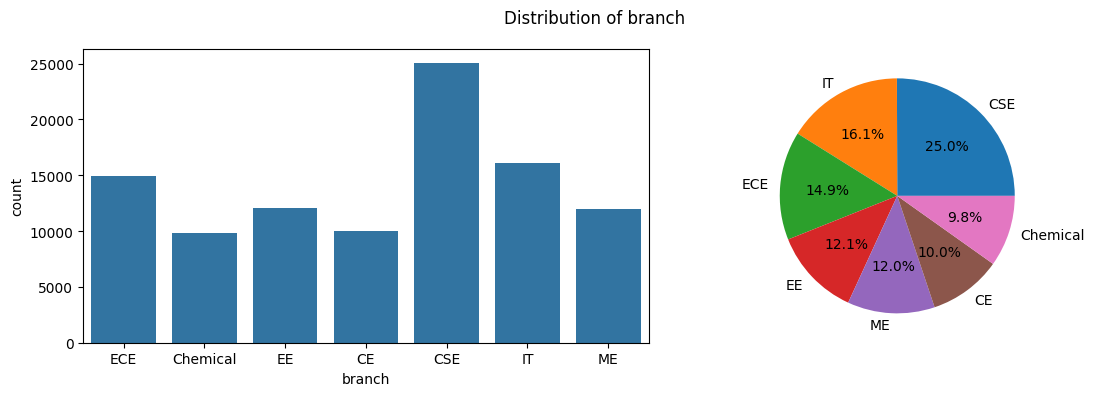

Counts of each category in college_tier:
college_tier
Tier-3    45222
Tier-2    39910
Tier-1    14868
Name: count, dtype: int64



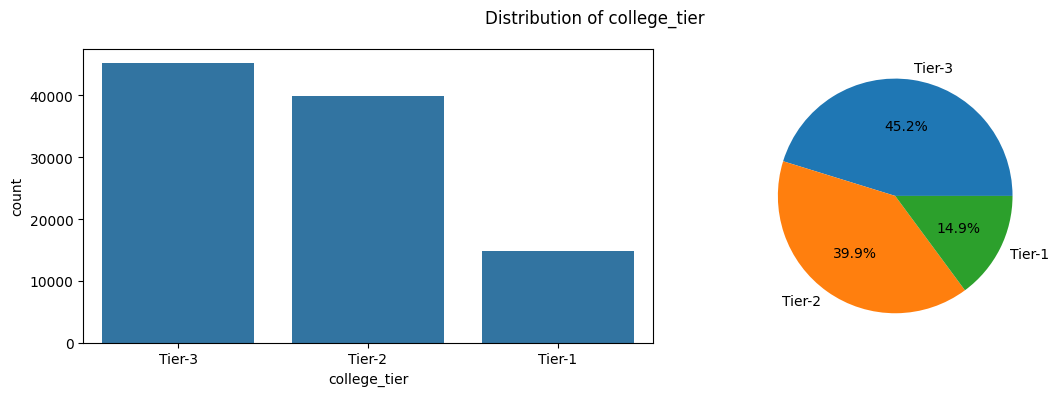

Counts of each category in placement_status:
placement_status
1    68475
0    31525
Name: count, dtype: int64



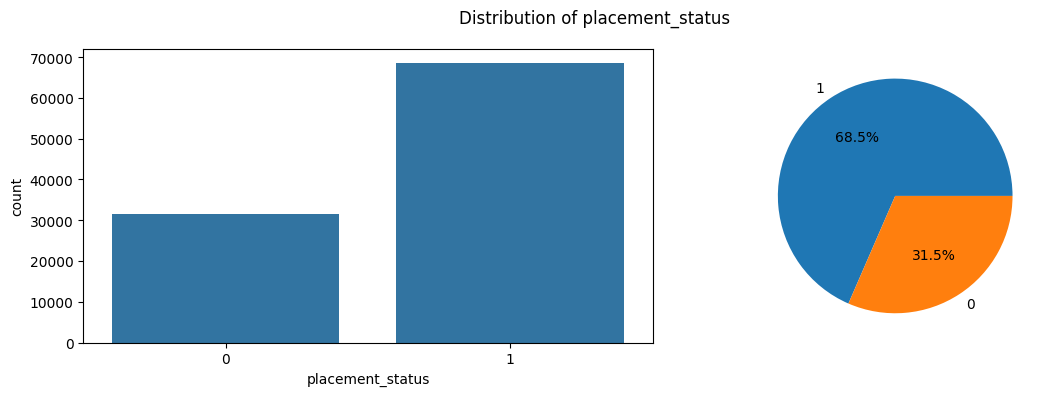

In [11]:
for col in categorical_cols:
    univariate_cat(df, col)

**Insights**
1. branch column shows imbalanced distribution, CSE branch as the majority branch and Chemical branch is in minority.
2. college_tier column shows imbalanced distribution, tier_3 is in majority and tier_1 is in minority.
2. placement_status column is moderately imbalanced, category 1 (placed) is in majority (68.5%) and category 0 (not placed) is in minority (31.5%), which indicates that majority of the students are placed.

In [12]:
def univariate_num(df, col):
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))

    # display the statistical summary
    summary = df[col].describe()
    print(f"Statistical summary of {col}:\n{summary}\n")
    print()
    print(f"Skewness: {df[col].skew()}")
    
    # plot histogram
    sns.histplot(df[col], kde=True, ax=ax[0])

    # plot boxplot
    sns.boxplot(y=df[col], ax=ax[1])

    plt.suptitle(f"Distribution of {col}")
    plt.tight_layout()
    plt.show()

Statistical summary of cgpa:
count    100000.000000
mean          7.206381
std           0.925235
min           4.000000
25%           6.580000
50%           7.210000
75%           7.830000
max          10.000000
Name: cgpa, dtype: float64


Skewness: -0.006300353115178814


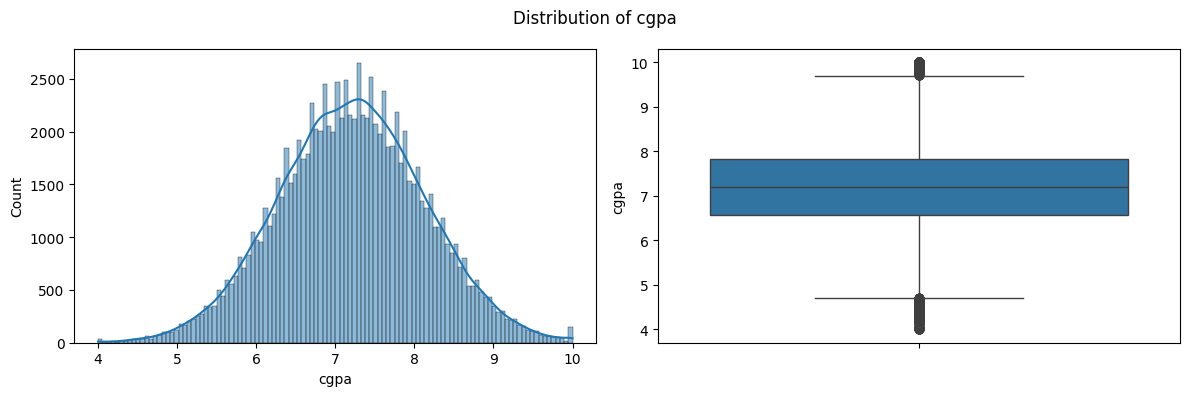

Statistical summary of backlogs:
count    100000.000000
mean          0.547010
std           0.862727
min           0.000000
25%           0.000000
50%           0.000000
75%           1.000000
max           3.000000
Name: backlogs, dtype: float64


Skewness: 1.479959999889171


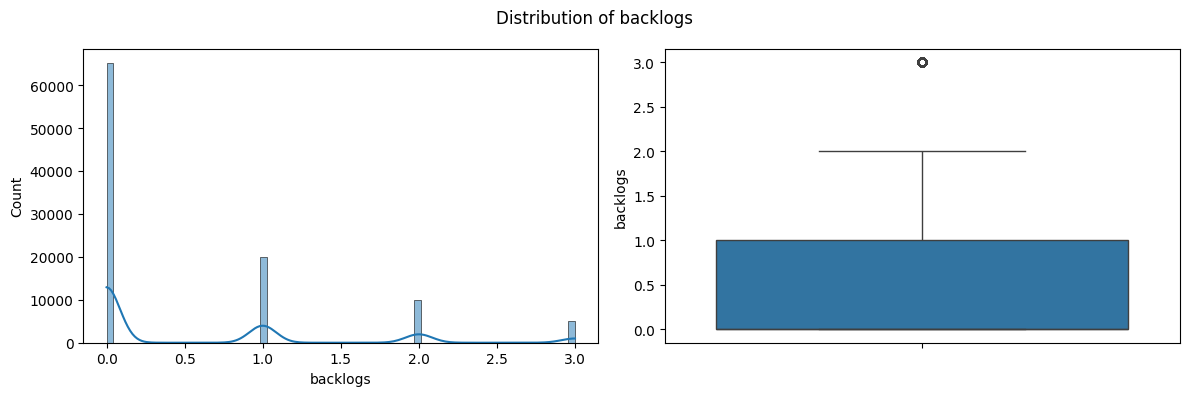

Statistical summary of coding_skills:
count    100000.000000
mean          5.995147
std           1.496302
min           1.000000
25%           5.000000
50%           6.000000
75%           7.000000
max          10.000000
Name: coding_skills, dtype: float64


Skewness: -0.030374848150489516


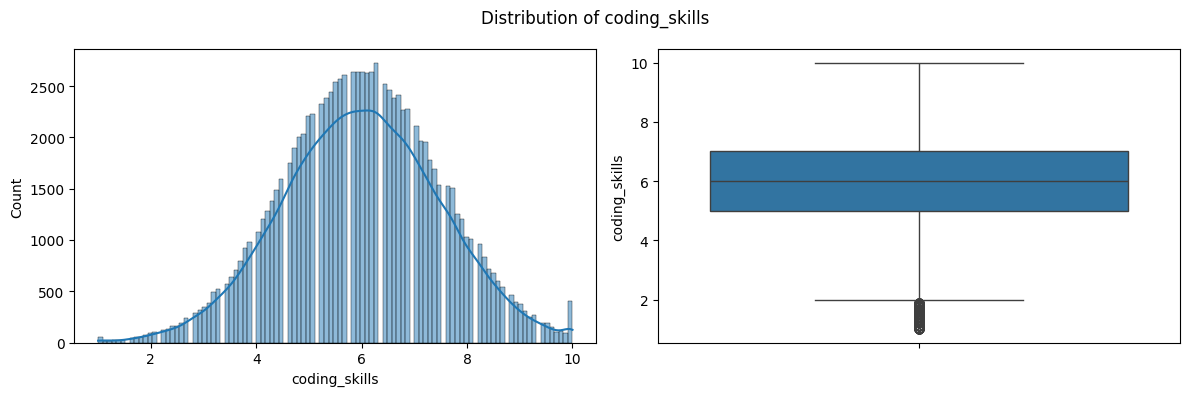

Statistical summary of dsa_score:
count    100000.000000
mean          5.500711
std           1.781961
min           1.000000
25%           4.300000
50%           5.500000
75%           6.700000
max          10.000000
Name: dsa_score, dtype: float64


Skewness: -0.0001573882961641489


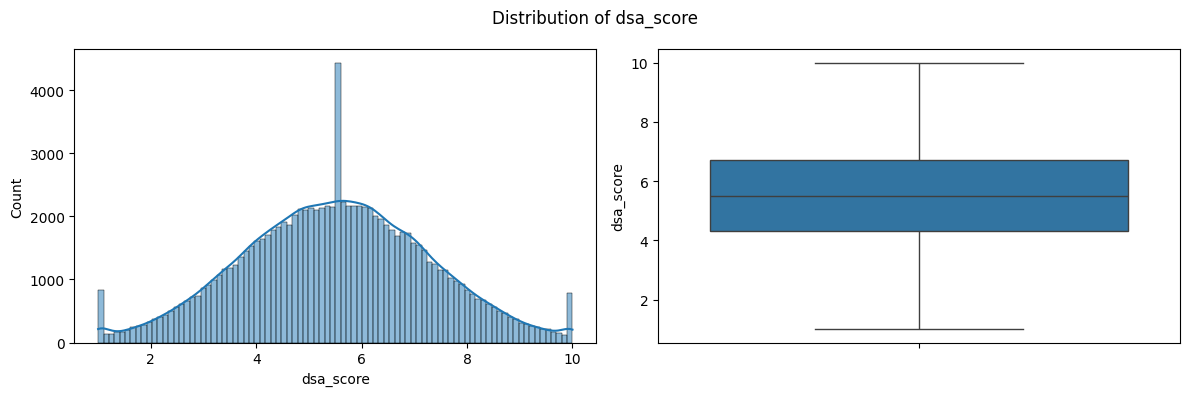

Statistical summary of aptitude_score:
count    100000.000000
mean         64.990511
std          11.990892
min          20.000000
25%          56.800000
50%          65.000000
75%          73.100000
max         100.000000
Name: aptitude_score, dtype: float64


Skewness: -0.0029255396912280054


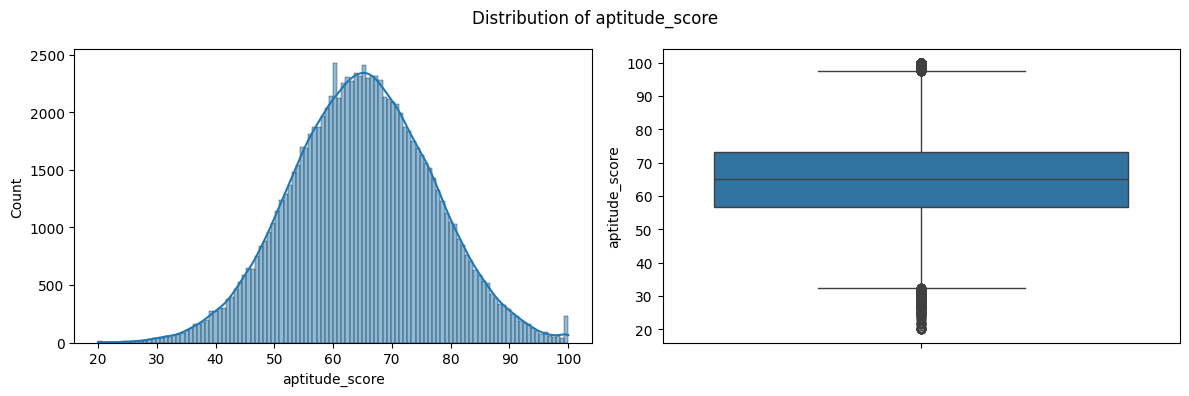

Statistical summary of communication_skills:
count    100000.000000
mean          5.990614
std           1.496552
min           1.000000
25%           5.000000
50%           6.000000
75%           7.000000
max          10.000000
Name: communication_skills, dtype: float64


Skewness: -0.023463532709394417


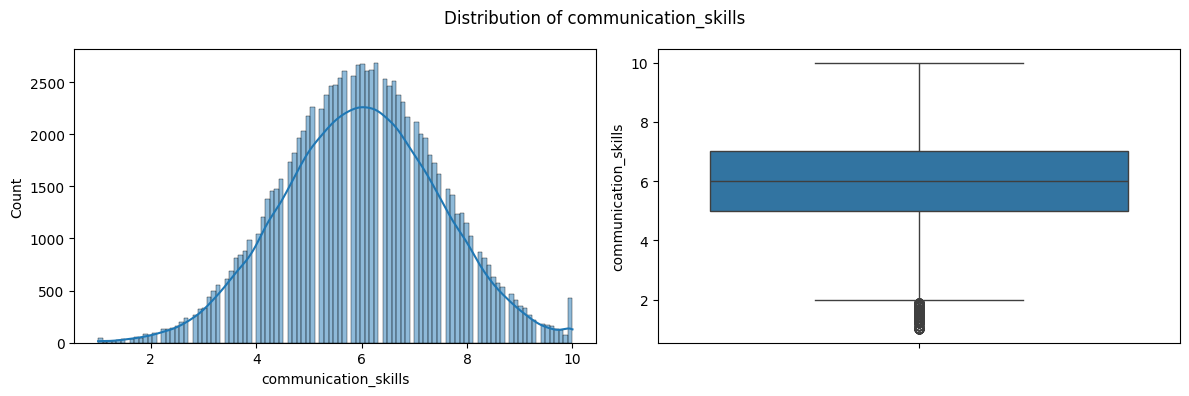

Statistical summary of ml_knowledge:
count    100000.000000
mean          4.508752
std           1.968278
min           0.000000
25%           3.200000
50%           4.500000
75%           5.900000
max          10.000000
Name: ml_knowledge, dtype: float64


Skewness: 0.05082191878958822


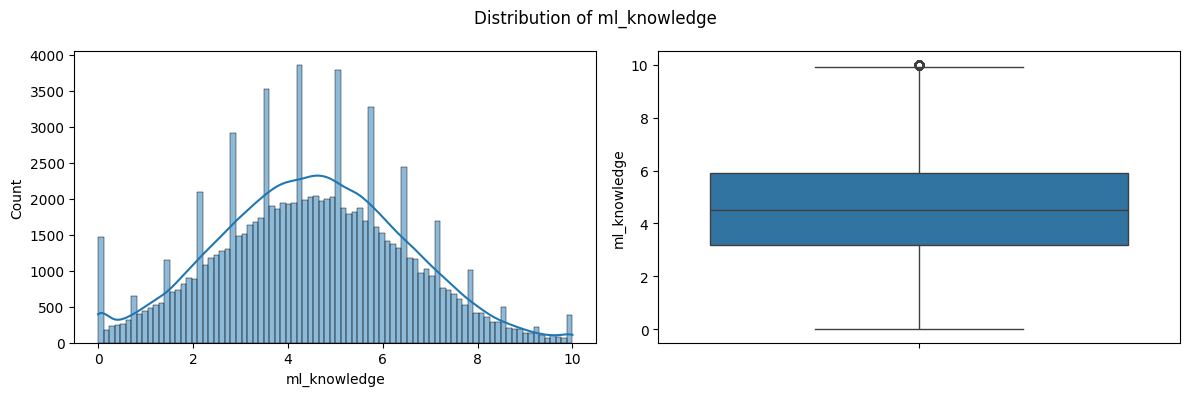

Statistical summary of system_design:
count    100000.000000
mean          4.008210
std           1.778405
min           0.000000
25%           2.800000
50%           4.000000
75%           5.200000
max          10.000000
Name: system_design, dtype: float64


Skewness: 0.07582199301777408


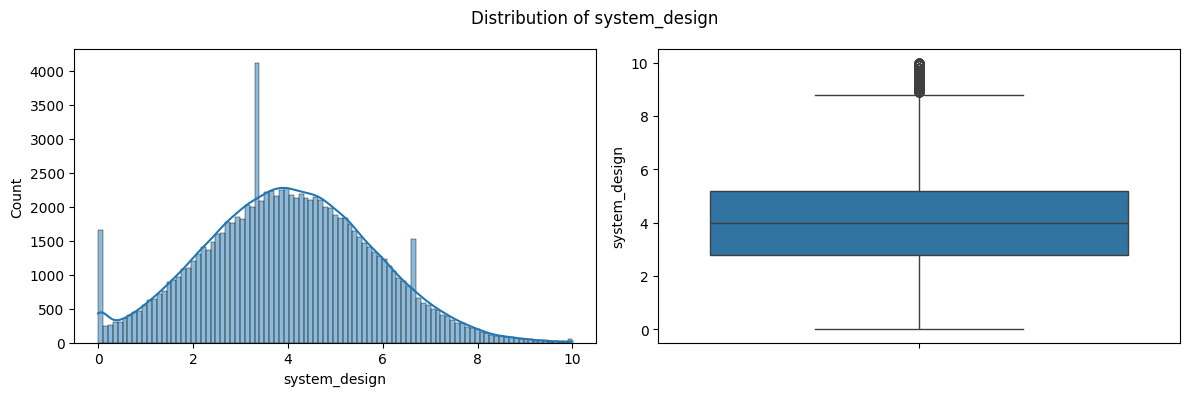

Statistical summary of internships:
count    100000.000000
mean          1.095040
std           0.940264
min           0.000000
25%           0.000000
50%           1.000000
75%           2.000000
max           3.000000
Name: internships, dtype: float64


Skewness: 0.5205966091888858


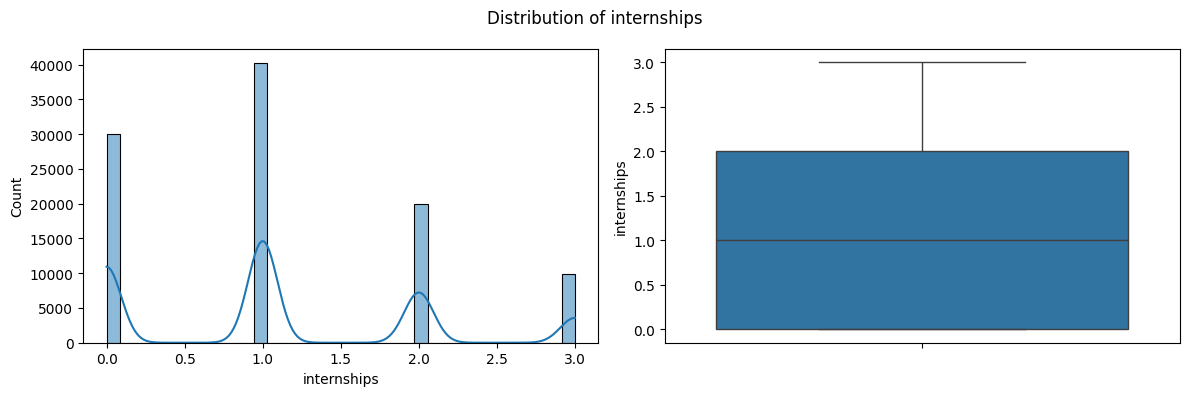

Statistical summary of projects_count:
count    100000.000000
mean          2.397280
std           1.242829
min           0.000000
25%           1.000000
50%           2.000000
75%           3.000000
max           5.000000
Name: projects_count, dtype: float64


Skewness: 0.15559661465117627


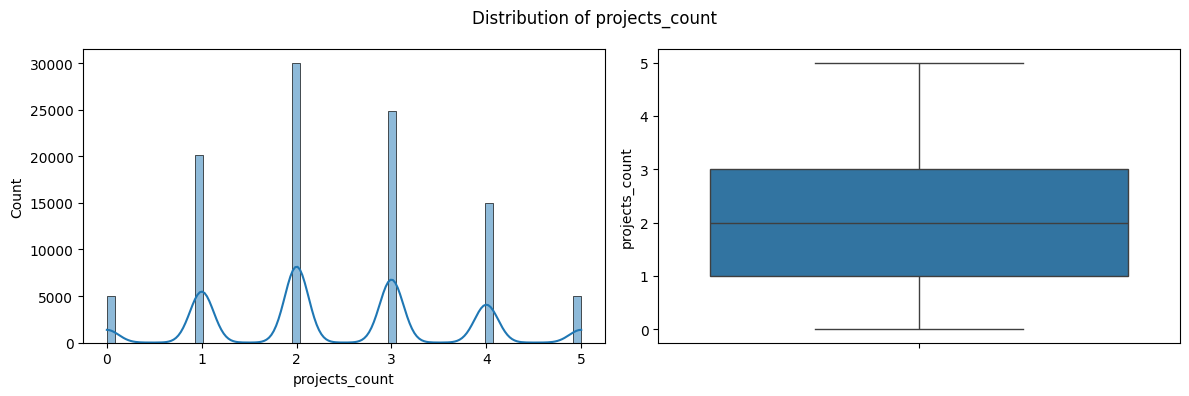

Statistical summary of certifications:
count    100000.00000
mean          1.49985
std           1.11407
min           0.00000
25%           1.00000
50%           1.00000
75%           2.00000
max           4.00000
Name: certifications, dtype: float64


Skewness: 0.4319921845382627


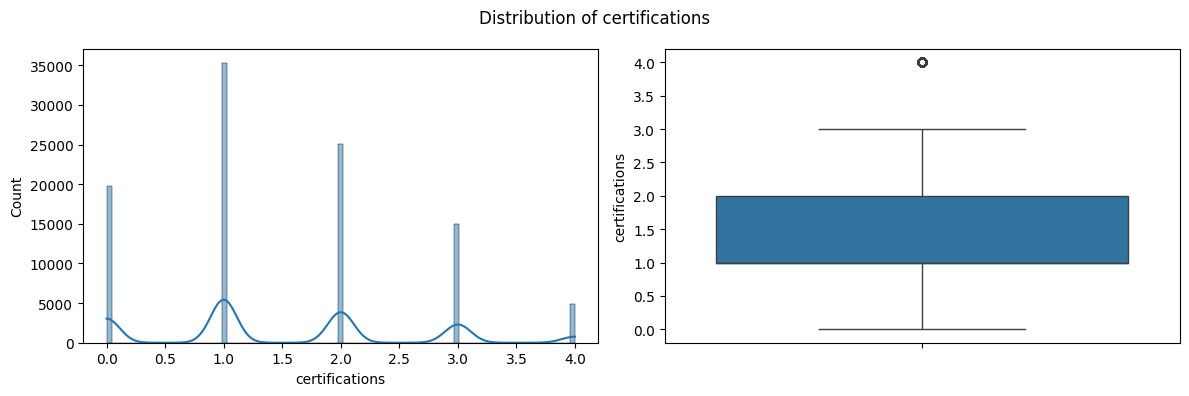

Statistical summary of hackathons:
count    100000.000000
mean          0.745840
std           0.884189
min           0.000000
25%           0.000000
50%           0.000000
75%           1.000000
max           3.000000
Name: hackathons, dtype: float64


Skewness: 0.9451437891574455


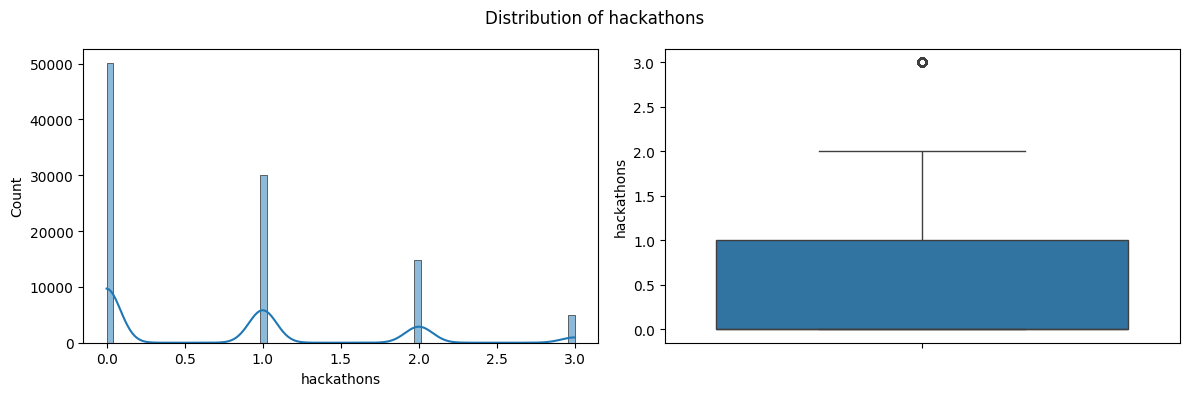

Statistical summary of open_source_contributions:
count    100000.000000
mean          0.450990
std           0.671061
min           0.000000
25%           0.000000
50%           0.000000
75%           1.000000
max           2.000000
Name: open_source_contributions, dtype: float64


Skewness: 1.1852204203438037


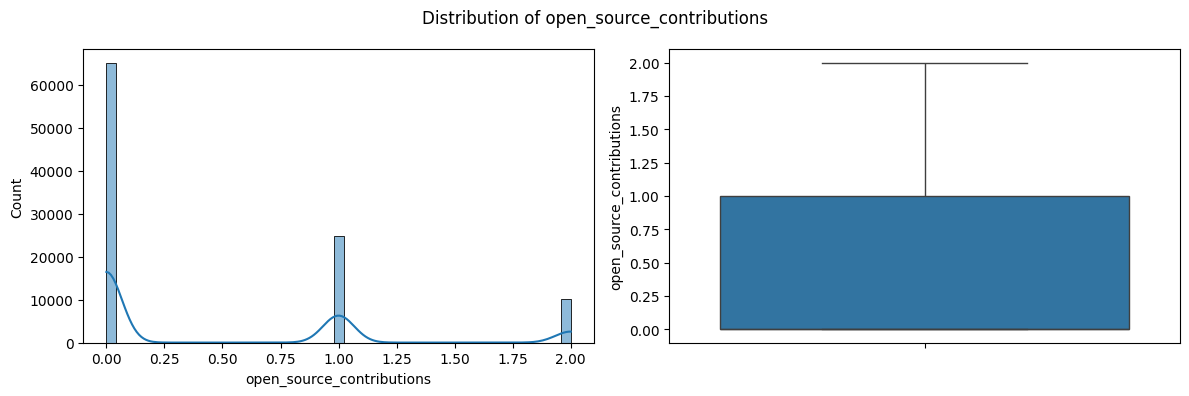

Statistical summary of extracurriculars:
count    100000.000000
mean          1.151100
std           0.965162
min           0.000000
25%           0.000000
50%           1.000000
75%           2.000000
max           3.000000
Name: extracurriculars, dtype: float64


Skewness: 0.37086378334773595


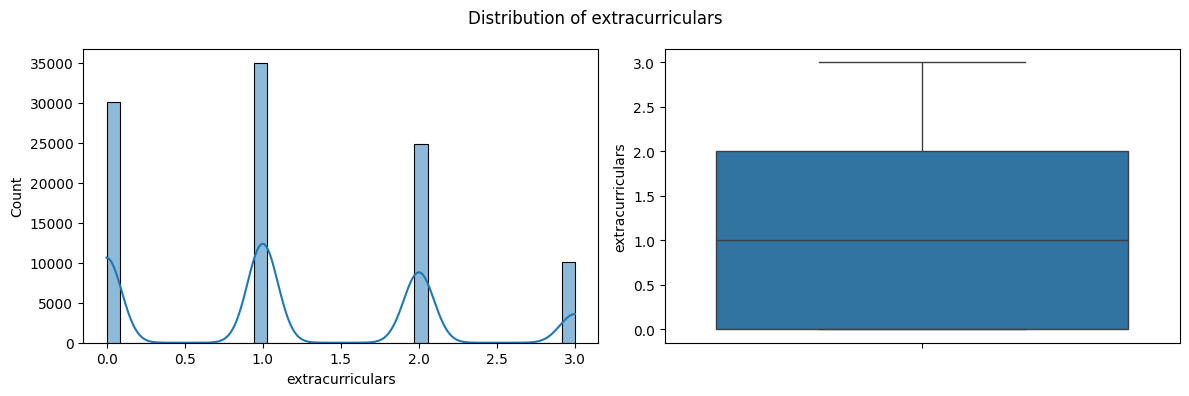

Statistical summary of salary_package_lpa:
count    68475.000000
mean        17.308014
std          2.601041
min          6.880000
25%         15.530000
50%         17.250000
75%         19.040000
max         28.330000
Name: salary_package_lpa, dtype: float64


Skewness: 0.11420013849552117


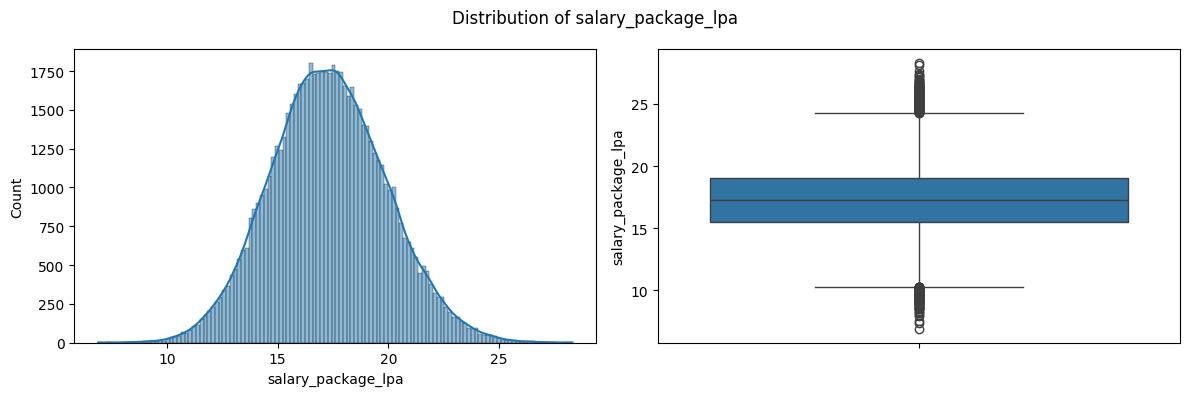

In [13]:
for col in numerical_cols:
    univariate_num(df, col)

**Insights**

1. The cgpa column is almost normally distributed, the right tail is fatter than left tail which indicates that density of students lies towards right side is higher than left side indicating that the students are focusing on their college studies. There are sudden spikes present in the data, the data contain outliers.

2. The coding_skills column is almost normally distributed, it's right tail is fatter than left one which indicates that the density of students lies towards right side is higher than left side. There are outliers present in the data.

3. The dsa_score column is almost normally distributed, both the tails of the graph are fat which indicates that the density of students at the extremes are high, there is spike shown around the the middle around 5.5 which indicates the most of the students have average level of dsa_score.

4. The aptitude column is almost normally distributed, the right tail is slightly fat than left tail, the data contain outliers.

5. The distribution of ml_knowledge column is almost normal, the left tail is slightly fatter than right one which indicates that the density of students lying on left side is higher than in right side indicates lesser knowledge in ml, many sudden spikes are also present around specific values, the data contains very less no. of outliers.

6. The distribution of system_design column is almost normal, the left tail is slightly fatter than right one which indicates that the density of students lying on left side is higher than in right side indicates lesser knowledge in system design, the data contains lots of outliers.

7. The distribution of communication_skills is almost normal, the right tail is fatter than left one which indicates that the density of students lying on right side is higher than in left side indicating good communication skill. The data contains outliers.

8. The distribution of backlogs column is imbalanced, majority of the students have 0 backlog.

9. The distribution of internships column is imbalanced, majority of the students have done one internship.

10. The distribution of certifications column is imbalanced, majority of the students have done one certification.

11. The distribution of projects_count column is imbalanced, majority of the students have done 2 projects.

12. The distribution of open_source_contribution column is imbalanced, majority of the students didn't contributed in any of the open source contribution.

13.  The distribution of hackathons column is imbalanced, majority of the students didn't participated in any of the hackathons.

14.  The distribution of extracurriculars column is imbalanced, majority of the students have done one extracurricular.

15. The distribution of salary_lpa is normally distributed with lots of outliers.

#### **Bivariate Analysis**

In [14]:
def bivariate_cat(df, col1, col2):
    # create a crosstab
    crosstab = pd.crosstab(df[col1], df[col2], normalize="index") * 100
    print(f"Crosstab of {col1} and {col2}:\n{crosstab}\n")
    
    # plot countplot
    plt.figure(figsize=(8, 4))
    sns.countplot(x=col1, hue=col2, data=df)
    plt.title(f"Countplot of {col1} by {col2}")
    plt.tight_layout()
    plt.show()

Crosstab of branch and placement_status:
placement_status          0          1
branch                                
CE                35.335196  64.664804
CSE               28.651282  71.348718
Chemical          35.446774  64.553226
ECE               30.423723  69.576277
EE                33.650347  66.349653
IT                29.106754  70.893246
ME                33.594270  66.405730



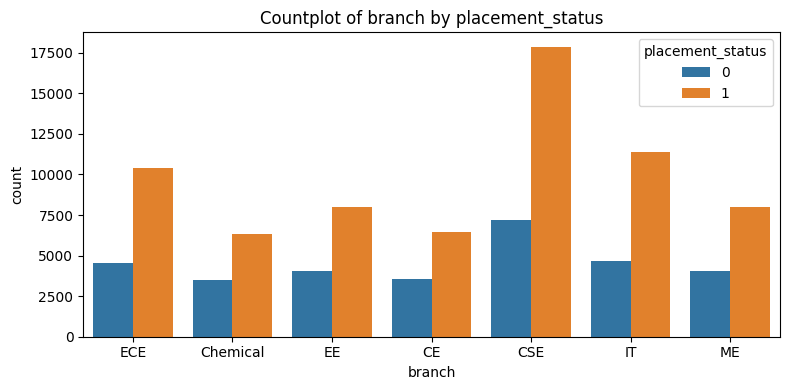

Crosstab of college_tier and placement_status:
placement_status          0          1
college_tier                          
Tier-1            16.942427  83.057573
Tier-2            27.439238  72.560762
Tier-3            39.925258  60.074742



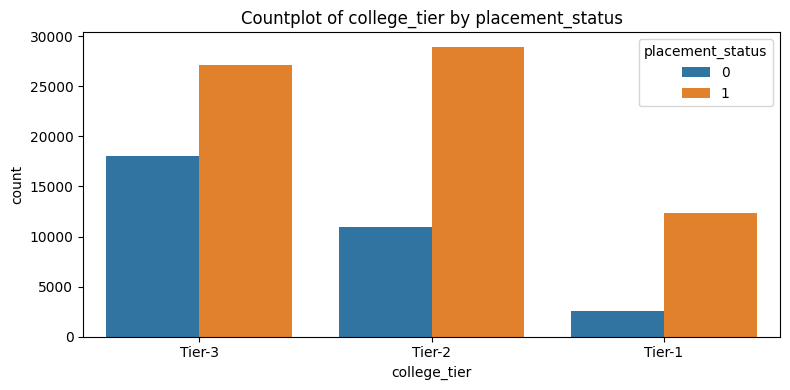

In [15]:
for col in categorical_cols:
    if col != "placement_status":
        bivariate_cat(df, col, "placement_status")
        print("="*110)

**Insight**
1. Students having CSE and IT branch tend to have high placement chances.
2. Students studying in tier_1 college tend to have high placement chances.

In [16]:
discrete_cols = [col for col in numerical_cols if df[col].nunique() < 10]
continuous_cols = [col for col in numerical_cols if df[col].nunique() >= 10]

print(f"Discrete numerical columns: {discrete_cols}")
print(f"Continuous numerical columns: {continuous_cols}")

Discrete numerical columns: ['backlogs', 'internships', 'projects_count', 'certifications', 'hackathons', 'open_source_contributions', 'extracurriculars']
Continuous numerical columns: ['cgpa', 'coding_skills', 'dsa_score', 'aptitude_score', 'communication_skills', 'ml_knowledge', 'system_design', 'salary_package_lpa']


Crosstab of backlogs and placement_status:
placement_status          0          1
backlogs                              
0                 29.840505  70.159495
1                 32.534760  67.465240
2                 36.895365  63.104635
3                 38.847621  61.152379



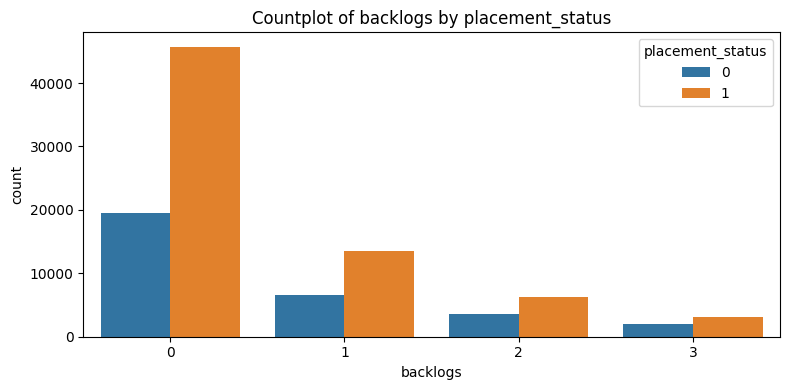

Crosstab of internships and placement_status:
placement_status          0          1
internships                           
0                 37.235529  62.764471
1                 31.715564  68.284436
2                 26.816261  73.183739
3                 22.815928  77.184072



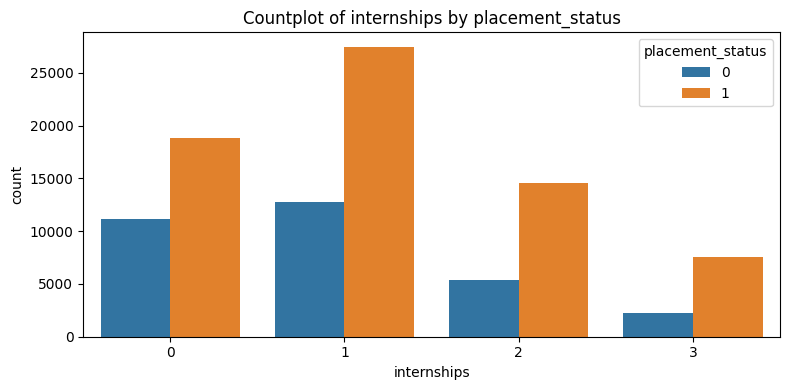

Crosstab of projects_count and placement_status:
placement_status          0          1
projects_count                        
0                 38.199562  61.800438
1                 35.007701  64.992299
2                 32.475155  67.524845
3                 30.146349  69.853651
4                 27.431972  72.568028
5                 24.260473  75.739527



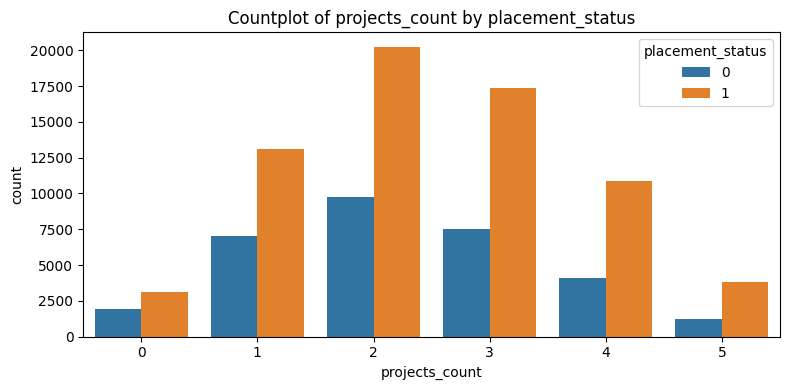

Crosstab of certifications and placement_status:
placement_status          0          1
certifications                        
0                 34.573769  65.426231
1                 32.956477  67.043523
2                 30.595376  69.404624
3                 27.628673  72.371327
4                 25.596442  74.403558



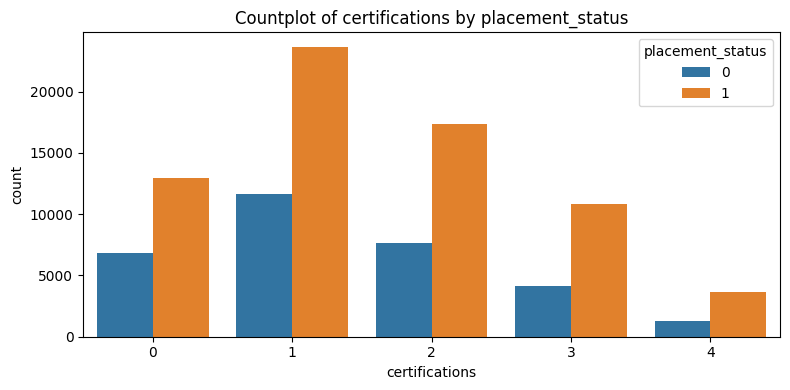

Crosstab of hackathons and placement_status:
placement_status          0          1
hackathons                            
0                 32.946858  67.053142
1                 30.724012  69.275988
2                 29.596986  70.403014
3                 27.766477  72.233523



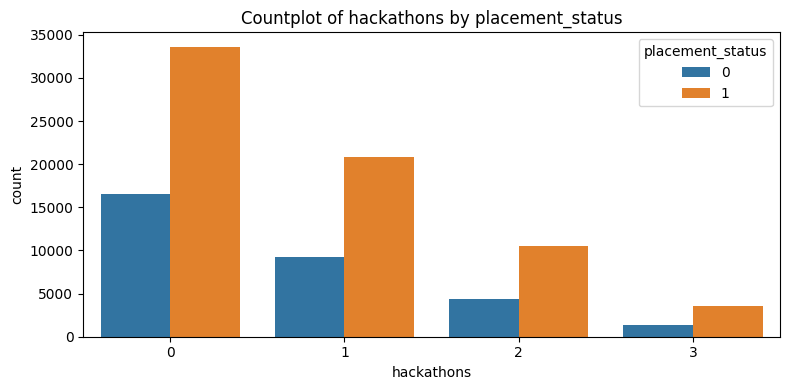

Crosstab of open_source_contributions and placement_status:
placement_status                   0          1
open_source_contributions                      
0                          32.287775  67.712225
1                          30.382245  69.617755
2                          29.429755  70.570245



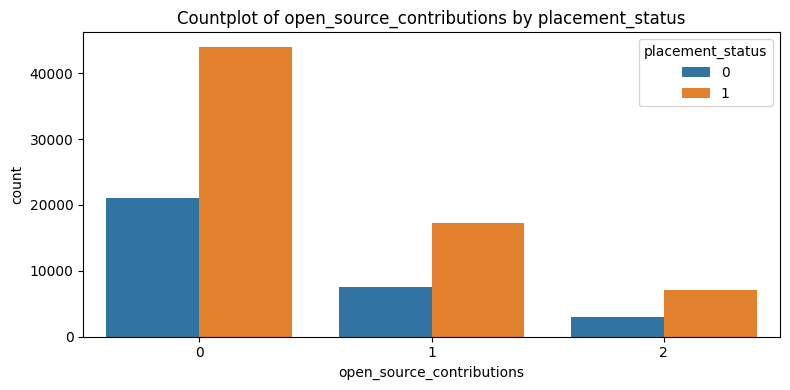

Crosstab of extracurriculars and placement_status:
placement_status          0          1
extracurriculars                      
0                 31.046655  68.953345
1                 31.645027  68.354973
2                 32.053396  67.946604
3                 31.231498  68.768502



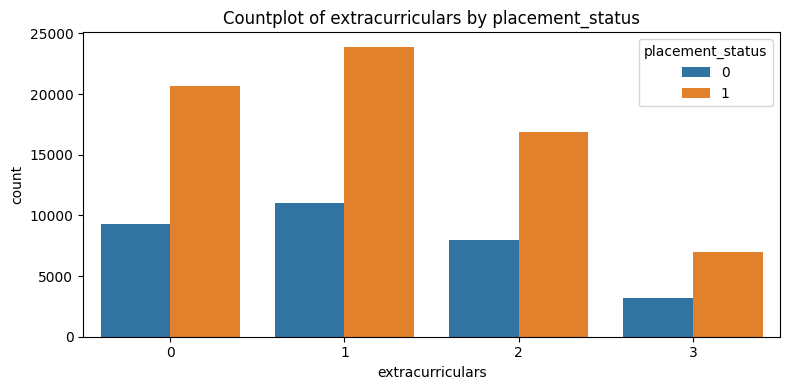

In [17]:
for col in discrete_cols:
    bivariate_cat(df, col, "placement_status")
    print("="*110)

**Insights**
1. Students having no backlogs tend to high chances of getting placed.
2. Students have done more no of internships tend to high chances of getting placed.
3. Students have done more no of certifications tend to high chances of getting placed.
4. Students have done more no of projects tend to high chances of getting placed.
5. Students have participated more no of hackathons tend to high chances of getting placed.
6. Students have participated more no of open_source_contribution tend to high chances of getting placed.

In [18]:
def bivariate_num(df, col1, col2):
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))

    # display the kde plot
    sns.kdeplot(x=col1, hue=col2, data=df, ax=ax[0])

    # display the boxplot
    sns.boxplot(x=col2, y=col1, data=df, ax=ax[1])

    plt.suptitle(f"Relationship between {col1} and {col2}")
    plt.tight_layout()
    plt.show()

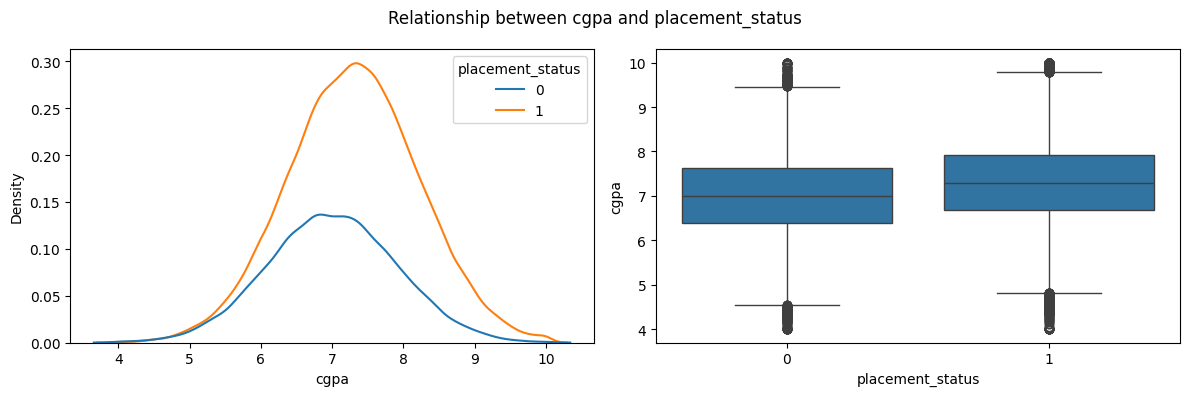

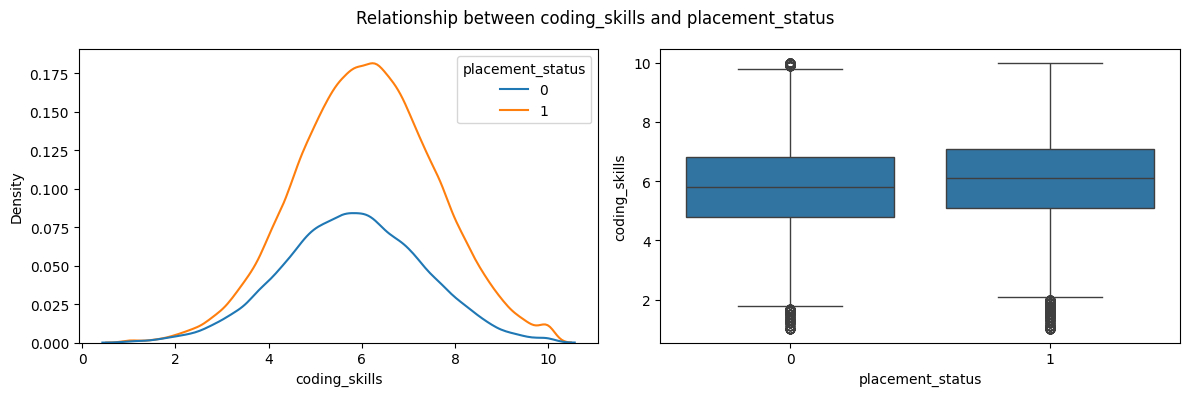

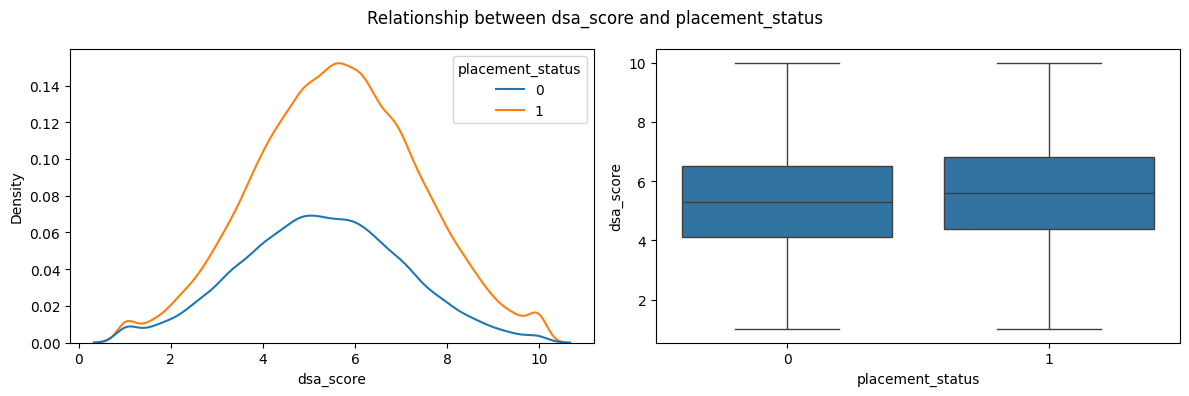

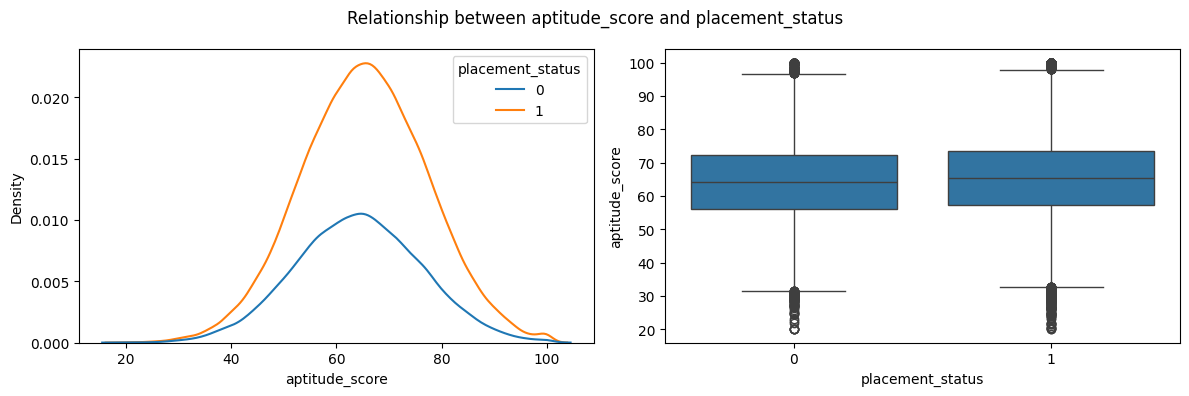

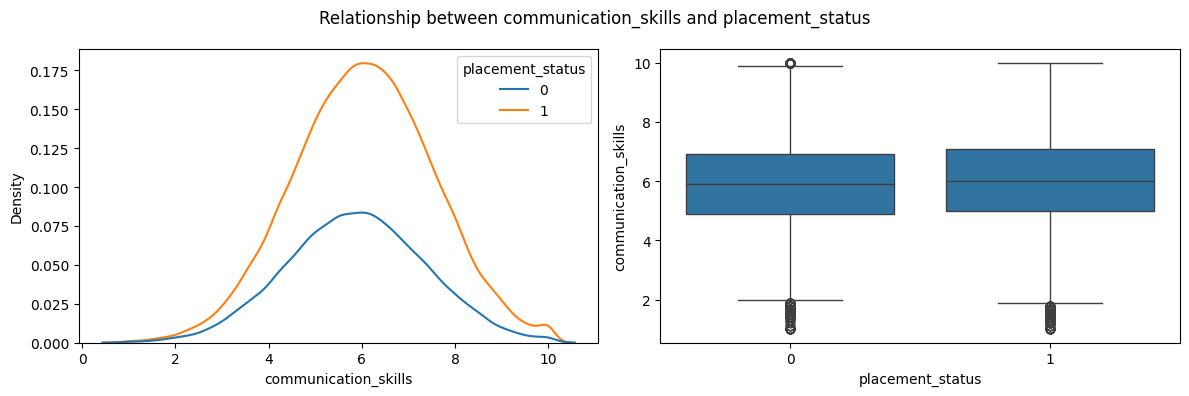

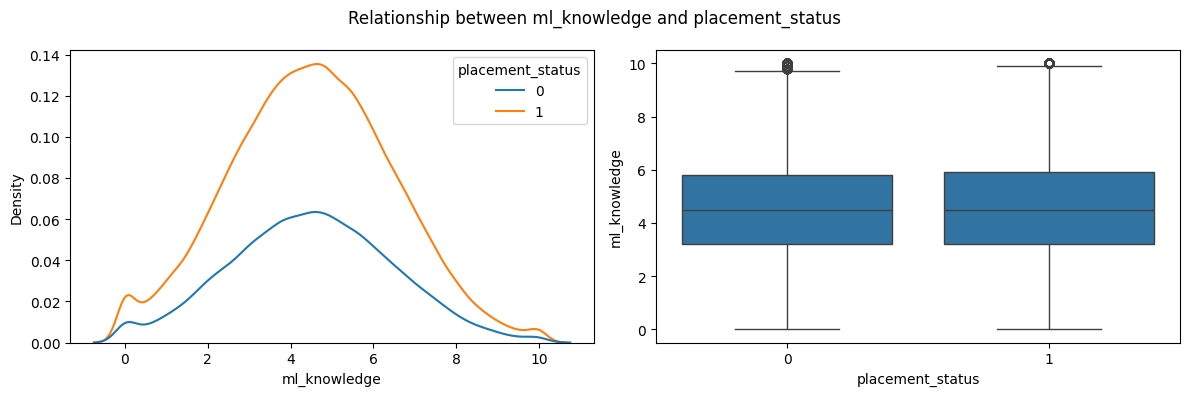

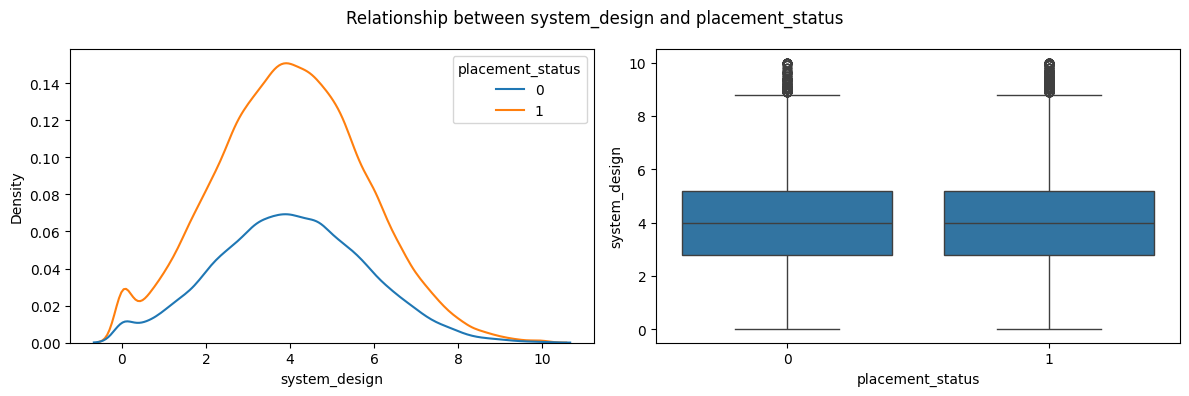

In [19]:
for col in continuous_cols:
    if col != "salary_package_lpa":
        bivariate_num(df, col, "placement_status")

**Insights**
1. Students having higher cgpa tend to have high chances of getting placed.
2. Students having higher communication_skills tend to have high chances of getting placed.
3. Students having higher dsa_score tend to have high chances of getting placed.

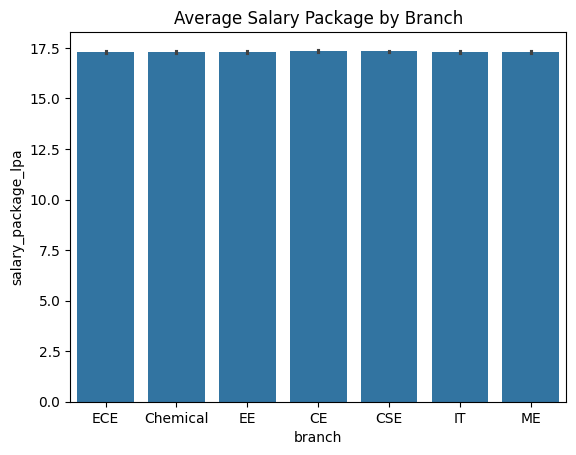

In [20]:
sns.barplot(df, x="branch", y="salary_package_lpa")
plt.title("Average Salary Package by Branch")
plt.show()

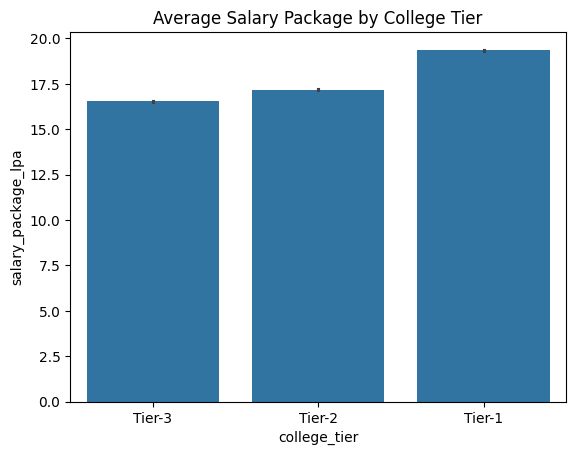

In [21]:
sns.barplot(df, x="college_tier", y="salary_package_lpa")
plt.title("Average Salary Package by College Tier")
plt.show()

**Insight**

Average salary package of tier_1 is higher than other tiers.

#### **Multivariate Analysis**

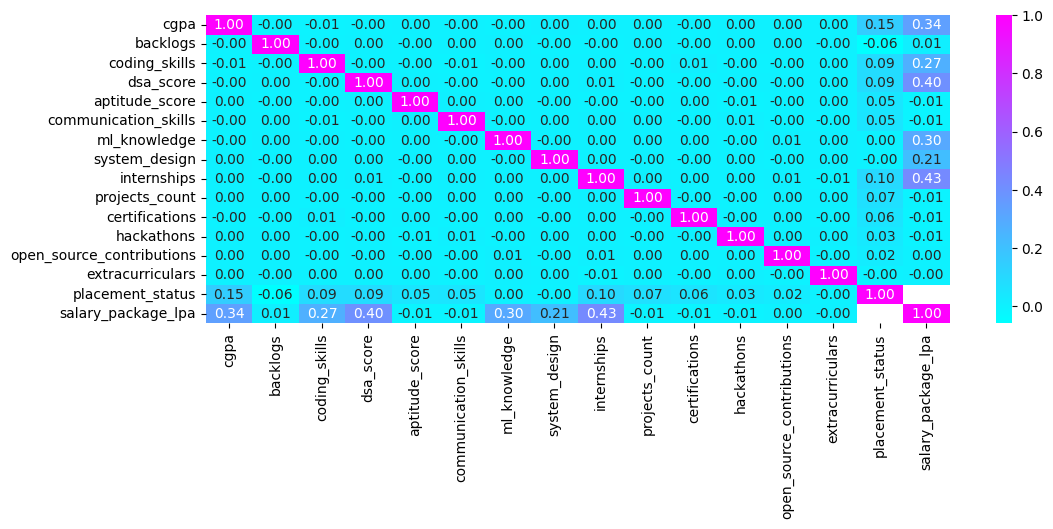

In [22]:
plt.figure(figsize=(12, 4))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="cool", fmt=".2f")
plt.show()

**Insights**
1. salary_package_lpa shows correlation with cgpa, coding_skills, dsa_score, ml_knowledge and internships.

#### **Conclusion**
From the analysis of the Student Placement dataset, it is observed that students with better academic performance, technical skills, and practical experience have higher chances of getting placed.

Students having higher CGPA, good DSA skills, better communication skills, more internships, projects, hackathons, certifications, and open-source contributions are more likely to get placement opportunities.

For salary prediction, factors like CGPA, coding skills, internships, ML knowledge, and DSA score play an important role in getting higher salary packages.

The dataset shows that placement depends not only on academics but also on practical exposure and skill development.

These insights can help students understand which skills are important for placements and can also help colleges improve training programs for students.

This dataset can be used to build:

- A classification model to predict whether a student will be placed or not.
- A regression model to predict the salary package of placed students.